# 03 - Commander Recommender System
### G1 - ManaCurve Analytics

Hybrid content-based + co-occurrence recommender for MTG Commander decks.

Required files (one level above notebook):
- `AllPrintings.json`
- `AllDeckFiles/` folder
- `oracle-cards.json` (Scryfall bulk)

In [1]:
import json
import random
import string
import warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

BASE_DIR= Path('../')
ALLPRINTINGS = BASE_DIR / 'AllPrintings.json'
ALLDECKFILES= BASE_DIR / 'AllDeckFiles'
SCRYFALL_ORACLE = BASE_DIR / 'oracle-cards.json'

for p in [ALLPRINTINGS, ALLDECKFILES, SCRYFALL_ORACLE]:
    print(f"{'OK' if p.exists() else 'MISSING'}  {p}")

OK  ../AllPrintings.json
OK  ../AllDeckFiles
OK  ../oracle-cards.json


## 1. Load & Feature Engineer Card Data

In [2]:
with open(ALLPRINTINGS, 'r', encoding='utf-8') as f:
    raw = json.load(f)

cards = []
for set_code, set_data in raw['data'].items():
    for card in set_data.get('cards', []):
        if card.get('legalities', {}).get('commander') == 'Legal':
            cards.append({
                'name':card.get('name'),
                'uuid':card.get('uuid'),
                'manaValue':card.get('manaValue'),
                'power':card.get('power'),
                'toughness':card.get('toughness'),
                'colors': card.get('colors'),
                'colorIdentity': card.get('colorIdentity'),
                'types':card.get('types'),
                'rarity':card.get('rarity'),
                'isLegendary': 'Legendary' in card.get('supertypes', []),
                'text':card.get('text', '')
            })

cards_df = pd.DataFrame(cards).drop_duplicates(subset=['name']).reset_index(drop=True)
cards_df['power']= pd.to_numeric(cards_df['power'],     errors='coerce')
cards_df['toughness']=pd.to_numeric(cards_df['toughness'], errors='coerce')
cards_df['isLegendary']= cards_df['isLegendary'].fillna(False).astype(bool)
cards_df['text'] = cards_df['text'].fillna('')

print(f'{cards_df.shape[0]:,} unique Commander legal cards')

30,465 unique Commander legal cards


In [3]:
ALL_COLORS = ['W', 'U', 'B', 'R', 'G']
MAJOR_TYPES = ['Creature', 'Instant', 'Sorcery', 'Artifact', 'Enchantment', 'Land']
RARITY_MAP= {'common': 1, 'uncommon': 2, 'rare': 3, 'mythic': 4}

cards_df['manaValue'] = cards_df['manaValue'].fillna(0)
cards_df['power_num']= pd.to_numeric(cards_df['power'],errors='coerce').fillna(0)
cards_df['toughness_num'] = pd.to_numeric(cards_df['toughness'],errors='coerce').fillna(0)
cards_df['text_length']= cards_df['text'].apply(len)
cards_df['num_colors']=cards_df['colors'].apply(lambda x: len(x) if isinstance(x, list) else 0)
cards_df['rarity_ord'] = cards_df['rarity'].str.lower().map(RARITY_MAP)
cards_df['rarity_ord'] = cards_df['rarity_ord'].fillna(cards_df['rarity_ord'].median())

for c in ALL_COLORS:
    cards_df[f'color_{c}'] = cards_df['colors'].apply(
        lambda x, c=c: int(c in x) if isinstance(x, list) else 0
    )

for t in MAJOR_TYPES:
    cards_df[f'type_{t}'] = cards_df['types'].apply(
        lambda x, t=t: int(t in x) if isinstance(x, list) else 0
    )

cards_df['is_creature'] = cards_df['type_Creature']
cards_df['is_land'] = cards_df['type_Land']
cards_df['is_artifact'] = cards_df['type_Artifact']
cards_df['has_rules_text'] = (cards_df['text_length'] > 0).astype(int)
cards_df['is_colorless'] = cards_df['colorIdentity'].apply(
    lambda x: int(len(x) == 0) if isinstance(x, list) else 1
)

name_to_idx = {name: i for i, name in enumerate(cards_df['name'])}

In [4]:
MTG_STOPWORDS = {
    'you', 'your', 'this', 'that', 'its', 'the', 'a', 'an', 'of', 'to',
    'in', 'on', 'and', 'or', 'with', 'from', 'at', 'when', 'whenever',
    'if', 'may', 'put', 'get', 'one', 'each', 'have', 'has', 'do', 'as',
    'until', 'end', 'turn', 'card', 'cards', 'player', 'players',
    'them', 'they', 'other', 'target', 'any', 'all', 'no'
}

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    return ' '.join(t for t in text.split() if t not in MTG_STOPWORDS and len(t) > 2)

cards_df['processed_text'] = cards_df['text'].apply(preprocess_text)
tfidf_vec = TfidfVectorizer(max_features=300, min_df=5, stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(cards_df['processed_text'])
tfidf_cols= [f'tfidf_{w}' for w in tfidf_vec.get_feature_names_out()]
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=cards_df.index)

print(f'TF-IDF shape: {tfidf_df.shape}')

TF-IDF shape: (30465, 300)


In [5]:
STRUCTURED_FEATURES = (
    ['manaValue', 'num_colors', 'text_length', 'rarity_ord',
     'power_num', 'toughness_num', 'is_creature', 'is_land',
     'is_artifact', 'has_rules_text', 'is_colorless'] +
    [f'color_{c}' for c in ALL_COLORS] +
    [f'type_{t}' for t in MAJOR_TYPES]
)

X_struct = cards_df[STRUCTURED_FEATURES].astype(float).fillna(0).copy()
scaler = MinMaxScaler()
cont_cols = ['manaValue', 'text_length', 'rarity_ord', 'power_num', 'toughness_num']
X_struct[cont_cols] = scaler.fit_transform(X_struct[cont_cols])

TFIDF_WEIGHT = 0.15
X_full = pd.concat([X_struct, tfidf_df * TFIDF_WEIGHT], axis=1).astype(float)

#colorless candidates scored against this matrix to avoid penalizing no color identity
COLOR_COLS = [f'color_{c}' for c in ALL_COLORS] + ['num_colors', 'is_colorless']
X_noncreature = X_struct.drop(columns=COLOR_COLS)

print(f'X_full: {X_full.shape}, X_noncreature: {X_noncreature.shape}')

X_full: (30465, 322), X_noncreature: (30465, 15)


## 2. Load Scryfall Oracle Cards EDHREC Ranks

In [6]:
with open(SCRYFALL_ORACLE, 'r', encoding='utf-8') as f:
    scryfall_raw = json.load(f)

scryfall_records = [
    {'name': c.get('name'), 'edhrec_rank': c.get('edhrec_rank')}
    for c in scryfall_raw
    if c.get('legalities', {}).get('commander') == 'legal'
]

scryfall_df = pd.DataFrame(scryfall_records)
MAX_RANK = scryfall_df['edhrec_rank'].max() + 1
scryfall_df['edhrec_rank'] = scryfall_df['edhrec_rank'].fillna(MAX_RANK)

cards_df = cards_df.merge(scryfall_df[['name', 'edhrec_rank']], on='name', how='left')
cards_df['edhrec_rank'] = cards_df['edhrec_rank'].fillna(MAX_RANK)

print(f'{len(scryfall_df):,} Scryfall records merged')
for c in ['Sol Ring', 'Lightning Greaves', 'Counterspell']:
    row = cards_df[cards_df['name'] == c]
    if not row.empty:
        print(f'{c} edhrec_rank: {int(row["edhrec_rank"].values[0]):,}')

30,969 Scryfall records merged
Sol Ring edhrec_rank: 1
Lightning Greaves edhrec_rank: 13
Counterspell edhrec_rank: 16


## 3. Load MTGJSON Decks & Build Co-occurrence Matrix

In [7]:
COMMANDER_TYPES = {'commander deck', 'mtgo commander deck'}
def parse_deck_file(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f).get('data', {})
    except Exception:
        return None
    if data.get('type', '').lower() not in COMMANDER_TYPES:
        return None
    commanders = [c['name'] for c in data.get('commander', []) if 'name' in c]
    mainboard  = [c['name'] for c in data.get('mainBoard', [])  if 'name' in c]
    if not commanders or not mainboard:
        return None
    return {
        'deck_name': data.get('name', path.stem),
        'commander': commanders,
        'cards': mainboard,
        'all_cards': commanders + mainboard
    }

deck_files = list(ALLDECKFILES.glob('*.json'))
all_decks= [d for p in deck_files if (d := parse_deck_file(p)) is not None]

print(f'{len(deck_files)} deck files found, {len(all_decks)} Commander decks parsed')

2711 deck files found, 183 Commander decks parsed


In [8]:
card_deck_count = defaultdict(int)
cooccurrence = defaultdict(lambda: defaultdict(int))

for deck in all_decks:
    valid = list(set(c for c in deck['all_cards'] if c in name_to_idx))
    for card in valid:
        card_deck_count[card] += 1
    for i in range(len(valid)):
        for j in range(i + 1, len(valid)):
            a, b = valid[i], valid[j]
            cooccurrence[a][b] += 1
            cooccurrence[b][a] += 1

n_decks = len(all_decks)
print(f'Co-occurrence matrix built from {n_decks} decks')
print(f'Unique cards tracked: {len(card_deck_count):,}')
for c in ['Sol Ring', 'Lightning Greaves', 'Arcane Signet']:
    if c in card_deck_count:
        pct = 100 * card_deck_count[c] / n_decks
        print(f'{c} {card_deck_count[c]}/{n_decks} decks ({pct:.1f}%)')

Co-occurrence matrix built from 183 decks
Unique cards tracked: 5,997
Sol Ring 179/183 decks (97.8%)
Lightning Greaves 39/183 decks (21.3%)
Arcane Signet 131/183 decks (71.6%)


In [9]:
def cooccurrence_scores_batch(candidate_names, deck_card_names):
    scores = np.zeros(len(candidate_names))
    for i, cand in enumerate(candidate_names):
        if cand not in cooccurrence or card_deck_count.get(cand, 0) == 0:
            continue
        vals = [cooccurrence[cand].get(dc, 0) / card_deck_count[cand] for dc in deck_card_names]
        scores[i] = float(np.mean(vals)) if vals else 0.0
    return scores

test_deck = ['Cultivate', "Kodama's Reach", 'Rampant Growth', 'Lightning Greaves']
for c in ['Sol Ring', 'Arcane Signet', 'Counterspell', 'Dark Ritual']:
    s = cooccurrence_scores_batch([c], test_deck)[0]
    print(f'  {c} {s:.4f}')

  Sol Ring 0.1648
  Arcane Signet 0.1603
  Counterspell 0.3750
  Dark Ritual 0.0000


## 4. Color Identity Helper

In [10]:
def get_color_identity(card_name):
    row = cards_df[cards_df['name'] == card_name]
    if row.empty:
        return set()
    ci = row.iloc[0]['colorIdentity']
    return set(ci) if isinstance(ci, list) else set()

for cmd in ["Ghalta, Primal Hunger", "Atraxa, Praetors' Voice",
            "Urza, Lord High Artificer", "Edgar Markov"]:
    print(f'{cmd} {get_color_identity(cmd)}')

Ghalta, Primal Hunger {'G'}
Atraxa, Praetors' Voice {'U', 'W', 'G', 'B'}
Urza, Lord High Artificer {'U'}
Edgar Markov {'W', 'R', 'B'}


## 5. Recommender

In [11]:
COMMANDER_WEIGHT = 3
CONTENT_WEIGHT = 0.5
COOCC_WEIGHT = 0.5


def recommend_cards(deck_card_names, commander_name, top_k=20, enforce_color_identity=True):
    all_deck_names = deck_card_names + [commander_name]
    deck_idx = cards_df[cards_df['name'].isin(all_deck_names)].index
    cmd_idx = cards_df[cards_df['name'] == commander_name].index

    commander_ci = get_color_identity(commander_name)
    excluded = set(deck_card_names) | {commander_name}
    candidates= cards_df[~cards_df['name'].isin(excluded)].copy()

    if enforce_color_identity and commander_ci:
        candidates = candidates[candidates['colorIdentity'].apply(
            lambda ci: set(ci).issubset(commander_ci) if isinstance(ci, list) else True
        )]

    #content similarity: all candidates vs full deck profile
    deck_vecs = X_full.loc[deck_idx].values
    cmd_vecs= X_full.loc[cmd_idx].values
    deck_stack = np.vstack([deck_vecs] + [cmd_vecs] * (COMMANDER_WEIGHT - 1))
    cand_vecs = X_full.loc[candidates.index].values
    sim_full = cosine_similarity(cand_vecs, deck_stack)
    content_scores = 0.5 * sim_full.mean(axis=1) +0.5 *sim_full.max(axis=1)

    #colorless candidates rescored vs non-creature deck cards only
    noncreature_idx = cards_df[
        cards_df['name'].isin(all_deck_names) &
        (cards_df['is_creature'] == 0) &
        (cards_df['is_land'] == 0)
    ].index
    colorless_mask = (candidates['is_colorless'] == 1).values

    if noncreature_idx.shape[0] > 0 and colorless_mask.sum() > 0:
        nc_vecs = X_noncreature.loc[noncreature_idx].values
        cl_vecs= X_noncreature.loc[candidates[colorless_mask].index].values
        sim_cl= cosine_similarity(cl_vecs, nc_vecs)
        scores_cl = 0.5 * sim_cl.mean(axis=1) + 0.5 * sim_cl.max(axis=1)
        cl_pos = np.where(colorless_mask)[0]
        content_scores[cl_pos] = np.maximum(content_scores[cl_pos], scores_cl)

    coocc_scores = cooccurrence_scores_batch(candidates['name'].tolist(), deck_card_names)
    final_scores = CONTENT_WEIGHT * content_scores + COOCC_WEIGHT * coocc_scores

    top_idx= np.argsort(final_scores)[::-1][:top_k]
    top_cands = candidates.iloc[top_idx].copy()
    top_cands['content_score'] = content_scores[top_idx].round(4)
    top_cands['coocc_score'] = coocc_scores[top_idx].round(4)
    top_cands['final_score'] = final_scores[top_idx].round(4)

    return top_cands[['name', 'manaValue', 'types', 'rarity',
                       'content_score','coocc_score', 'final_score']].reset_index(drop=True)

## 6. Example Recommendations

In [12]:
#Select MTGJSON decks for evaluation and examples
MIN_DECK_SIZE = 20
CARDS_TO_HIDE= 6
MAX_EVAL_DECKS = 30

eval_decks = []
for deck in all_decks:
    valid = [c for c in deck['cards'] if c in name_to_idx]
    cmd = deck['commander'][0] if deck['commander'] else None
    if cmd and cmd in name_to_idx and len(valid) >= MIN_DECK_SIZE:
        eval_decks.append({
            'deck_name': deck['deck_name'],
            'commander': cmd,
            'cards': valid,
            'cards_to_hide': CARDS_TO_HIDE
        })
    if len(eval_decks) >= MAX_EVAL_DECKS:
        break

print(f'{len(eval_decks)} decks selected')
for d in eval_decks[:5]:
    print(f"{d['deck_name']}, {d['commander']} | {len(d['cards'])} cards")

30 decks selected
Scions & Spellcraft (FINAL FANTASY XIV), Y'shtola, Night's Blessed | 97 cards
Timey-Wimey, The Tenth Doctor | 95 cards
Enhanced Evolution, Otrimi, the Ever-Playful | 89 cards
Counterpunch, Ghave, Guru of Spores | 85 cards
Witherbloom Witchcraft, Willowdusk, Essence Seer | 81 cards


In [13]:
for deck in eval_decks[:4]:
    print(f"{deck['deck_name']} — {deck['commander']}")
    display(recommend_cards(deck['cards'], deck['commander'], top_k=15))

Scions & Spellcraft (FINAL FANTASY XIV) — Y'shtola, Night's Blessed


,name,manaValue,types,rarity,content_score,coocc_score,final_score
0,God-Pharaoh's Gift,7.0,[Artifact],rare,0.8431,0.2784,0.5607
1,The Golden Throne,4.0,[Artifact],rare,0.8427,0.2784,0.5605
2,Inquisitorial Rosette,2.0,[Artifact],rare,0.8415,0.2784,0.5599
3,Knight Paladin,5.0,[Artifact],rare,0.8318,0.2784,0.5551
4,Thunderhawk Gunship,6.0,[Artifact],rare,0.8315,0.2784,0.5549
5,Gate to the Afterlife,3.0,[Artifact],uncommon,0.8254,0.2784,0.5519
6,Reaver Titan,7.0,[Artifact],rare,0.8120,0.2784,0.5452
7,Sigiled Sword of Valeron,3.0,[Artifact],rare,0.8422,0.2474,0.5448
8,Liquimetal Torque,2.0,[Artifact],uncommon,0.8304,0.2474,0.5389
9,Dungeon Map,3.0,[Artifact],uncommon,0.8324,0.2371,0.5347


Timey-Wimey — The Tenth Doctor


,name,manaValue,types,rarity,content_score,coocc_score,final_score
0,T-45 Power Armor,2.0,[Artifact],rare,0.8476,0.2632,0.5554
1,Brotherhood Vertibird,3.0,[Artifact],rare,0.8451,0.2632,0.5541
2,Nuka-Cola Vending Machine,3.0,[Artifact],uncommon,0.8344,0.2632,0.5488
3,Endurance Bobblehead,3.0,[Artifact],uncommon,0.8341,0.2632,0.5486
4,Expert-Level Safe,2.0,[Artifact],uncommon,0.8336,0.2632,0.5484
5,C.A.M.P.,3.0,[Artifact],uncommon,0.8308,0.2632,0.5470
6,Intelligence Bobblehead,3.0,[Artifact],uncommon,0.8274,0.2632,0.5453
7,The Chain Veil,4.0,[Artifact],mythic,0.8520,0.2316,0.5418
8,"Bessie, the Doctor's Roadster",2.0,[Artifact],rare,0.8444,0.2211,0.5327
9,Ace's Baseball Bat,2.0,[Artifact],rare,0.8426,0.2211,0.5318


Enhanced Evolution — Otrimi, the Ever-Playful


,name,manaValue,types,rarity,content_score,coocc_score,final_score
0,Savvy Trader,4.0,[Creature],rare,0.8145,0.2697,0.5421
1,Tower Winder,2.0,[Creature],rare,0.8134,0.2697,0.5415
2,"Doc Aurlock, Grizzled Genius",2.0,[Creature],uncommon,0.8030,0.2697,0.5363
3,"Gonti, Canny Acquisitor",5.0,[Creature],mythic,0.8028,0.2697,0.5362
4,Felix Five-Boots,5.0,[Creature],mythic,0.8010,0.2697,0.5353
5,Orochi Soul-Reaver,6.0,[Creature],rare,0.7988,0.2697,0.5343
6,Smirking Spelljacker,5.0,[Creature],rare,0.7984,0.2697,0.5340
7,Silhana Ledgewalker,2.0,[Creature],common,0.7978,0.2697,0.5337
8,Dream-Thief's Bandana,2.0,[Artifact],rare,0.7966,0.2697,0.5332
9,Sagu Mauler,6.0,[Creature],rare,0.8059,0.2584,0.5321


Counterpunch — Ghave, Guru of Spores


,name,manaValue,types,rarity,content_score,coocc_score,final_score
0,"Skullbriar, the Walking Grave",2.0,[Creature],rare,0.7966,0.2824,0.5395
1,Troll Ascetic,3.0,[Creature],rare,0.7935,0.2824,0.5379
2,Desecrator Hag,4.0,[Creature],common,0.7884,0.2824,0.5354
3,Archon of Valor's Reach,6.0,[Creature],rare,0.7989,0.2706,0.5347
4,Angel of Despair,7.0,[Creature],rare,0.7868,0.2824,0.5346
5,"Tayam, Luminous Enigma",4.0,[Creature],mythic,0.7958,0.2706,0.5332
6,"Kathril, Aspect Warper",5.0,[Creature],mythic,0.7957,0.2706,0.5331
7,"Yannik, Scavenging Sentinel",4.0,[Creature],mythic,0.7949,0.2706,0.5327
8,Gwyllion Hedge-Mage,3.0,[Creature],uncommon,0.7821,0.2824,0.5322
9,Splinterfright,3.0,[Creature],rare,0.7922,0.2706,0.5314


## 7. Reconstruction-Based Evaluation

Hold out cards from MTGJSON Commander decklists, run the recommender on the
remaining cards, measure how often held out cards appear in Top-K.

Metrics: Hit Rate@K, Recall@K

In [14]:
def reconstruction_evaluation(eval_decks, recommend_func, k=20, n_trials=10, seed=42):
    random.seed(seed)
    results=[]

    for deck in eval_decks:
        valid= deck['cards']
        n_hide = deck['cards_to_hide']
        if len(valid) <= n_hide:
            continue

        trial_scores = []
        for _ in range(n_trials):
            hidden = random.sample(valid, n_hide)
            remaining = [c for c in valid if c not in hidden]
            try:
                recs = recommend_func(remaining, deck['commander'], top_k=k)
            except Exception:
                continue
            if recs.empty:
                continue
            rec_names = set(recs['name'].tolist())
            hits = sum(1 for c in hidden if c in rec_names)
            trial_scores.append(hits / n_hide)

        if trial_scores:
            results.append({
                'deck_name':deck['deck_name'],
                'commander':deck['commander'],
                'n_cards':len(valid),
                'k':k,
                'hit_rate_at_k': round(np.mean(trial_scores), 4),
                'recall_at_k':round(np.mean(trial_scores), 4),
                'best_trial': round(max(trial_scores), 4)
            })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        agg = pd.DataFrame([{
            'deck_name':'AGGREGATE',
            'commander':'',
            'n_cards':'',
            'k':k,
            'hit_rate_at_k': round(results_df['hit_rate_at_k'].mean(), 4),
            'recall_at_k': round(results_df['recall_at_k'].mean(), 4),
            'best_trial': round(results_df['best_trial'].mean(), 4)
        }])
        results_df = pd.concat([results_df, agg], ignore_index=True)

    return results_df

eval_results = reconstruction_evaluation(eval_decks, recommend_cards, k=20, n_trials=10)
display(eval_results)

,deck_name,commander,n_cards,k,hit_rate_at_k,recall_at_k,best_trial
0,Scions & Spellcraft (FINAL FANTASY XIV),"Y'shtola, Night's Blessed",97,20,0.7000,0.7000,0.8333
1,Timey-Wimey,The Tenth Doctor,95,20,0.2000,0.2000,0.5000
2,Enhanced Evolution,"Otrimi, the Ever-Playful",89,20,0.5333,0.5333,0.8333
3,Counterpunch,"Ghave, Guru of Spores",85,20,0.4333,0.4333,0.8333
4,Witherbloom Witchcraft,"Willowdusk, Essence Seer",81,20,0.7000,0.7000,1.0000
5,Divine Convocation,"Kasla, the Broken Halo",78,20,0.6833,0.6833,0.8333
6,Science!,Dr. Madison Li,92,20,0.4667,0.4667,0.6667
7,Death Toll,"Winter, Cynical Opportunist",89,20,0.5667,0.5667,0.8333
8,Chaos Incarnate,"Kardur, Doomscourge",78,20,0.3500,0.3500,0.6667
9,Tricky Terrain Collector's Edition,"Omo, Queen of Vesuva",96,20,0.8500,0.8500,1.0000


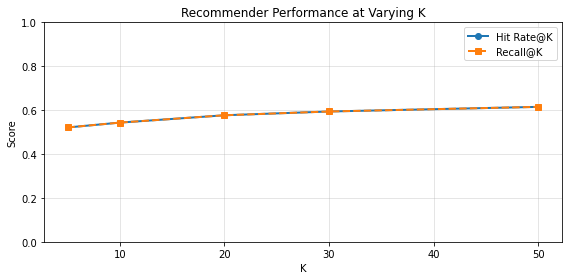

,k,hit_rate_at_k,recall_at_k
0,5,0.5211,0.5211
1,10,0.5433,0.5433
2,20,0.5767,0.5767
3,30,0.5939,0.5939
4,50,0.6150,0.6150


In [16]:
k_values = [5, 10, 20, 30, 50]
k_rows = []

for k in k_values:
    res = reconstruction_evaluation(eval_decks, recommend_cards, k=k, n_trials=10)
    agg = res[res['deck_name'] == 'AGGREGATE']
    if not agg.empty:
        k_rows.append({
            'k':k,
            'hit_rate_at_k': agg['hit_rate_at_k'].values[0],
            'recall_at_k': agg['recall_at_k'].values[0]
        })

k_df = pd.DataFrame(k_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_df['k'], k_df['hit_rate_at_k'], marker='o', linewidth=2, label='Hit Rate@K')
ax.plot(k_df['k'], k_df['recall_at_k'], marker='s', linewidth=2, linestyle='--', label='Recall@K')
ax.set_xlabel('K')
ax.set_ylabel('Score')
ax.set_title('Recommender Performance at Varying K')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
display(k_df)

## 8. EDHREC Benchmark — Precision@K

For each deck, hold out cards and measure what fraction of our Top-K
recommendations were actual cards from the real deck

Precision@K = |recommended ∩ held-out| / K

In [17]:
def edhrec_top_cards(commander_name, exclude_names, n=50):
    commander_ci = get_color_identity(commander_name)
    excluded = set(exclude_names) | {commander_name}
    pool = cards_df[~cards_df['name'].isin(excluded)].copy()
    if commander_ci:
        pool = pool[pool['colorIdentity'].apply(
            lambda ci: set(ci).issubset(commander_ci) if isinstance(ci, list) else True
        )]
    return set(pool.nsmallest(n, 'edhrec_rank')['name'].tolist())

def precision_at_k_evaluation(eval_decks, recommend_func, k=20, n_trials=10, seed=42):
    random.seed(seed)
    results = []

    for deck in eval_decks:
        valid = deck['cards']
        n_hide = deck['cards_to_hide']
        if len(valid) <= n_hide:
            continue

        trial_precisions = []
        for _ in range(n_trials):
            hidden = random.sample(valid, n_hide)
            remaining = [c for c in valid if c not in hidden]
            try:
                recs = recommend_func(remaining, deck['commander'], top_k=k)
            except Exception:
                continue
            if recs.empty:
                continue
            rec_names = set(recs['name'].tolist())
            #cards we know belong in this deck but aren't in the input
            ground_truth = set(hidden)
            trial_precisions.append(len(rec_names & ground_truth) / k)

        if trial_precisions:
            results.append({
                'deck_name': deck['deck_name'],
                'commander': deck['commander'],
                'precision_at_k': round(np.mean(trial_precisions), 4)
            })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        agg = pd.DataFrame([{
            'deck_name': 'AGGREGATE',
            'commander': '',
            'precision_at_k': round(results_df['precision_at_k'].mean(), 4)
        }])
        results_df = pd.concat([results_df, agg], ignore_index=True)

    return results_df

edhrec_results = precision_at_k_evaluation(eval_decks, recommend_cards, k=20, n_trials=10)
display(edhrec_results)

,deck_name,commander,precision_at_k
0,Scions & Spellcraft (FINAL FANTASY XIV),"Y'shtola, Night's Blessed",0.210
1,Timey-Wimey,The Tenth Doctor,0.060
2,Enhanced Evolution,"Otrimi, the Ever-Playful",0.160
3,Counterpunch,"Ghave, Guru of Spores",0.130
4,Witherbloom Witchcraft,"Willowdusk, Essence Seer",0.210
5,Divine Convocation,"Kasla, the Broken Halo",0.205
6,Science!,Dr. Madison Li,0.140
7,Death Toll,"Winter, Cynical Opportunist",0.170
8,Chaos Incarnate,"Kardur, Doomscourge",0.105
9,Tricky Terrain Collector's Edition,"Omo, Queen of Vesuva",0.255


## 9. Baseline Comparison

Popularity baseline: recommend the highest EDHREC-ranked color-legal cards
not already in the deck. No deck-awareness.

In [18]:
def recommend_cards_baseline(deck_card_names, commander_name, top_k=20):
    commander_ci = get_color_identity(commander_name)
    excluded= set(deck_card_names) | {commander_name}
    candidates = cards_df[~cards_df['name'].isin(excluded)].copy()
    if commander_ci:
        candidates = candidates[candidates['colorIdentity'].apply(
            lambda ci: set(ci).issubset(commander_ci) if isinstance(ci, list) else True
        )]
    return candidates.nsmallest(top_k, 'edhrec_rank')[['name', 'manaValue', 'types', 'rarity']].reset_index(drop=True)

baseline_recon = reconstruction_evaluation(eval_decks, recommend_cards_baseline, k=20, n_trials=10)
baseline_prec = precision_at_k_evaluation(eval_decks, recommend_cards_baseline, k=20, n_trials=10)

model_agg = eval_results[eval_results['deck_name'] == 'AGGREGATE']
baseline_agg = baseline_recon[baseline_recon['deck_name'] == 'AGGREGATE']
model_prec = edhrec_results[edhrec_results['deck_name'] == 'AGGREGATE']
base_prec= baseline_prec[baseline_prec['deck_name'] == 'AGGREGATE']

comparison = pd.DataFrame({
    'Model':['Content + Co-occurrence (ours)', 'Popularity baseline'],
    'Hit Rate@20': [model_agg['hit_rate_at_k'].values[0],baseline_agg['hit_rate_at_k'].values[0]],
    'Recall@20': [model_agg['recall_at_k'].values[0], baseline_agg['recall_at_k'].values[0]],
    'Precision@20':[model_prec['precision_at_k'].values[0], base_prec['precision_at_k'].values[0]]
})

print('Model vs baseline')
display(comparison)

Model vs baseline


,Model,Hit Rate@20,Recall@20,Precision@20
0,Content + Co-occurrence (ours),0.5767,0.5767,0.1730
1,Popularity baseline,0.0983,0.0983,0.0295


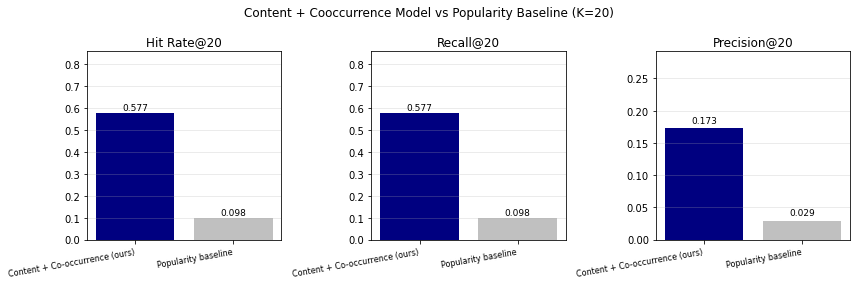

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ['Hit Rate@20', 'Recall@20', 'Precision@20']
colors= ['navy', 'silver']

for ax, metric in zip(axes, metrics):
    vals = comparison[metric].values
    labels = comparison['Model'].values
    bars = ax.bar(labels, vals, color=colors)
    ax.set_title(metric)
    ax.set_ylim(0, max(vals) * 1.4 + 0.05)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8, rotation=10, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Content + Cooccurrence Model vs Popularity Baseline (K=20)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Summary

**What was built:**
- Content-based cosine similarity over structured card features + TF-IDF rules text
- Dual-pass scoring so colorless staples are not penalized for having no color identity
- Co-occurrence matrix from real MTGJSON Commander precon decklists
- Hard color identity enforcement as a candidate filter
- Commander weighted 3x in deck profile to reflect its central role
- Reconstruction evaluation (Hit Rate@K, Recall@K) on real MTGJSON decks
- EDHREC benchmark (Precision@K) via Scryfall edhrec_rank
- Popularity baseline comparison across all three metrics

**Limitations / next steps:**
- Co-occurrence data limited to precon decks (~100 decks) — real Moxfield scale would be tens of thousands and would dramatically improve collaborative filtering signal
- TF-IDF captures keyword overlap but not semantic similarity — word embeddings are a natural next step
- CONTENT_WEIGHT, COOCC_WEIGHT, and COMMANDER_WEIGHT were set heuristically and should be tuned systematically

## 11. Model Comparison Experiments

Systematically evaluates different model configurations by varying content/co-occurrence
weight splits, commander weight, and TF-IDF weight. All experiments use the same
eval_decks, K=20, and 10 trials per deck.

In [ ]:
def build_recommend_fn(content_w, coocc_w, commander_w, tfidf_w):
    X_full_local = pd.concat([X_struct, tfidf_df * tfidf_w], axis=1).astype(float)

    def _recommend(deck_card_names, commander_name, top_k=20, enforce_color_identity=True):
        all_deck_names = deck_card_names + [commander_name]
        deck_idx = cards_df[cards_df['name'].isin(all_deck_names)].index
        cmd_idx = cards_df[cards_df['name'] == commander_name].index
        commander_ci = get_color_identity(commander_name)
        excluded = set(deck_card_names) | {commander_name}
        candidates= cards_df[~cards_df['name'].isin(excluded)].copy()

        if enforce_color_identity and commander_ci:
            candidates = candidates[candidates['colorIdentity'].apply(
                lambda ci: set(ci).issubset(commander_ci) if isinstance(ci, list) else True
            )]

        if candidates.empty:
            return pd.DataFrame()

        deck_vecs= X_full_local.loc[deck_idx].values
        cmd_vecs= X_full_local.loc[cmd_idx].values
        deck_stack = np.vstack([deck_vecs] + [cmd_vecs]*(commander_w - 1))
        cand_vecs = X_full_local.loc[candidates.index].values
        sim_full= cosine_similarity(cand_vecs, deck_stack)
        content_scores = 0.5 * sim_full.mean(axis=1) + 0.5 * sim_full.max(axis=1)

        noncreature_idx = cards_df[
            cards_df['name'].isin(all_deck_names) &
            (cards_df['is_creature'] == 0) &
            (cards_df['is_land'] == 0)
        ].index
        colorless_mask = (candidates['is_colorless'] == 1).values

        if noncreature_idx.shape[0] > 0 and colorless_mask.sum() > 0:
            nc_vecs= X_noncreature.loc[noncreature_idx].values
            cl_vecs= X_noncreature.loc[candidates[colorless_mask].index].values
            sim_cl = cosine_similarity(cl_vecs, nc_vecs)
            scores_cl = 0.5 * sim_cl.mean(axis=1) + 0.5 * sim_cl.max(axis=1)
            cl_pos = np.where(colorless_mask)[0]
            content_scores[cl_pos] = np.maximum(content_scores[cl_pos], scores_cl)

        coocc_scores =cooccurrence_scores_batch(candidates['name'].tolist(), deck_card_names)
        final_scores= content_w * content_scores + coocc_w * coocc_scores

        top_idx= np.argsort(final_scores)[::-1][:top_k]
        top_cands = candidates.iloc[top_idx].copy()
        top_cands['final_score'] = final_scores[top_idx].round(4)

        return top_cands[['name', 'manaValue', 'types', 'rarity', 'final_score']].reset_index(drop=True)

    return _recommend


In [28]:
EXPERIMENTS = [
    ('Content Only',1.0, 0.0, 3, 0.15),
    ('Co-occurrence Only',0.0, 1.0,  3, 0.15),
    ('Hybrid 50/50 (Ours)', 0.5, 0.5,  3, 0.15),
    ('Hybrid 70/30 (Content Heavy)', 0.7, 0.3, 3, 0.15),
    ('Hybrid 30/70 (Coocc Heavy)', 0.3, 0.7, 3, 0.15),
    ('Commander Weight = 1',0.5, 0.5,  1, 0.15),
    ('Commander Weight = 5', 0.5, 0.5, 5, 0.15),
    ('No TF-IDF', 0.5, 0.5, 3, 0.0),
    ('High TF-IDF (0.3x)',0.5, 0.5, 3, 0.3),
    ('Popularity Baseline',None, None, None, None),
]

K=20
N_TRIALS=10
SEED=42

results = []

for label, cw, ow, cmw, tw in EXPERIMENTS:
    print(f'  Running: {label}...')
    fn = recommend_cards_baseline if label == 'Popularity Baseline' \
         else build_recommend_fn(cw, ow, cmw, tw)
    res = reconstruction_evaluation(eval_decks, fn, k=K, n_trials=N_TRIALS, seed=SEED)
    agg = res[res['deck_name'] == 'AGGREGATE']
    if not agg.empty:
        results.append({
            'Model':label,
            'content_w':cw,
            'coocc_w': ow,
            'commander_w':cmw,
            'tfidf_w':tw,
            'hit_rate_at_k': agg['hit_rate_at_k'].values[0],
            'recall_at_k': agg['recall_at_k'].values[0],
            'best_trial': agg['best_trial'].values[0]
        })

results_df = pd.DataFrame(results).sort_values('hit_rate_at_k', ascending=False).reset_index(drop=True)

display(results_df[['Model', 'hit_rate_at_k', 'recall_at_k', 'best_trial']])

  Running: Content Only...
  Running: Co-occurrence Only...
  Running: Hybrid 50/50 (Ours)...
  Running: Hybrid 70/30 (Content Heavy)...
  Running: Hybrid 30/70 (Coocc Heavy)...
  Running: Commander Weight = 1...
  Running: Commander Weight = 5...
  Running: No TF-IDF...
  Running: High TF-IDF (0.3x)...
  Running: Popularity Baseline...


,Model,hit_rate_at_k,recall_at_k,best_trial
0,Co-occurrence Only,0.6167,0.6167,0.8555
1,Hybrid 30/70 (Coocc Heavy),0.5995,0.5995,0.8500
2,Commander Weight = 1,0.5783,0.5783,0.8444
3,Hybrid 50/50 (Ours),0.5767,0.5767,0.8444
4,High TF-IDF (0.3x),0.5761,0.5761,0.8444
5,No TF-IDF,0.5756,0.5756,0.8444
6,Commander Weight = 5,0.5739,0.5739,0.8444
7,Hybrid 70/30 (Content Heavy),0.5133,0.5133,0.7778
8,Popularity Baseline,0.0983,0.0983,0.2778
9,Content Only,0.0011,0.0011,0.0056


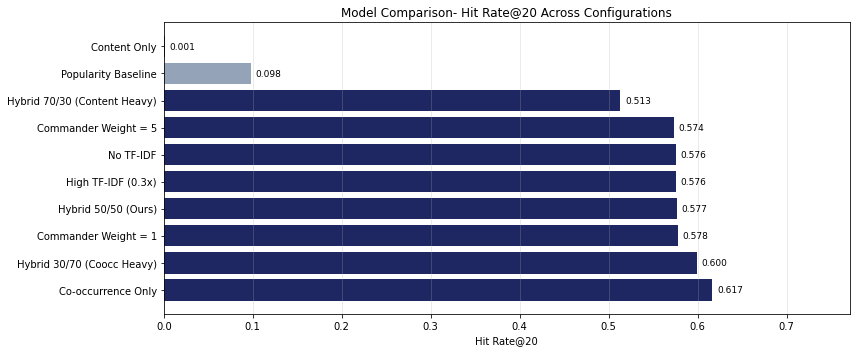

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#94A3B8' if m == 'Popularity Baseline' else '#1E2761'
          for m in results_df['Model']]

bars = ax.barh(results_df['Model'], results_df['hit_rate_at_k'], color=colors)
ax.set_xlabel('Hit Rate@20')
ax.set_title('Model Comparison- Hit Rate@20 Across Configurations')
ax.set_xlim(0, max(results_df['hit_rate_at_k']) * 1.25)
ax.grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, results_df['hit_rate_at_k']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

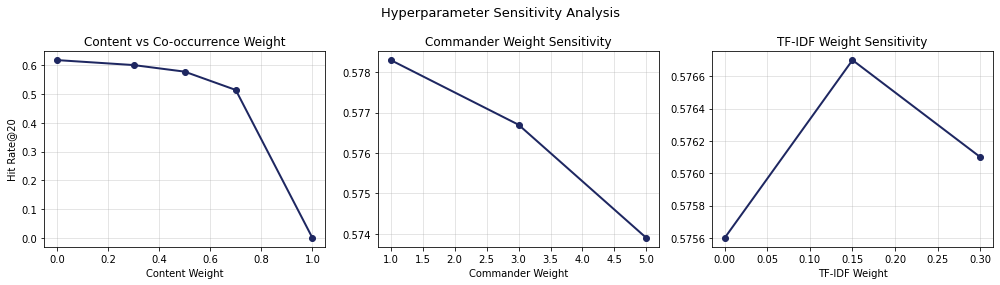

Best configuration:
  Co-occurrence Only | Hit Rate@20: 0.6167


In [27]:
weight_models = ['Content Only', 'Hybrid 30/70 (Coocc Heavy)', 'Hybrid 50/50 (Ours)',
                 'Hybrid 70/30 (Content Heavy)', 'Co-occurrence Only']
weight_df = results_df[results_df['Model'].isin(weight_models)].sort_values('content_w')

cmd_models = ['Commander Weight = 1', 'Hybrid 50/50 (Ours)', 'Commander Weight = 5']
cmd_df = results_df[results_df['Model'].isin(cmd_models)].sort_values('commander_w')

tfidf_models = ['No TF-IDF', 'Hybrid 50/50 (Ours)', 'High TF-IDF (0.3x)']
tfidf_df_plot = results_df[results_df['Model'].isin(tfidf_models)].sort_values('tfidf_w')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(weight_df['content_w'], weight_df['hit_rate_at_k'], marker='o', color='#1E2761', linewidth=2)
axes[0].set_xlabel('Content Weight')
axes[0].set_ylabel('Hit Rate@20')
axes[0].set_title('Content vs Co-occurrence Weight')
axes[0].grid(True, alpha=0.4)

axes[1].plot(cmd_df['commander_w'], cmd_df['hit_rate_at_k'], marker='o', color='#1E2761', linewidth=2)
axes[1].set_xlabel('Commander Weight')
axes[1].set_title('Commander Weight Sensitivity')
axes[1].grid(True, alpha=0.4)

axes[2].plot(tfidf_df_plot['tfidf_w'], tfidf_df_plot['hit_rate_at_k'], marker='o', color='#1E2761', linewidth=2)
axes[2].set_xlabel('TF-IDF Weight')
axes[2].set_title('TF-IDF Weight Sensitivity')
axes[2].grid(True, alpha=0.4)

plt.suptitle('Hyperparameter Sensitivity Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print('Best configuration:')
best = results_df.iloc[0]
print(f"  {best['Model']} | Hit Rate@20: {best['hit_rate_at_k']:.4f}")